In [ ]:
import torch
import torch.nn as nn

In [11]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data          # shape (70000, 784)
y = mnist.target        # string labels → convert to int if needed
y = y.astype('int')


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/7, random_state=42
)


In [15]:
X_train.shape

(60000, 784)

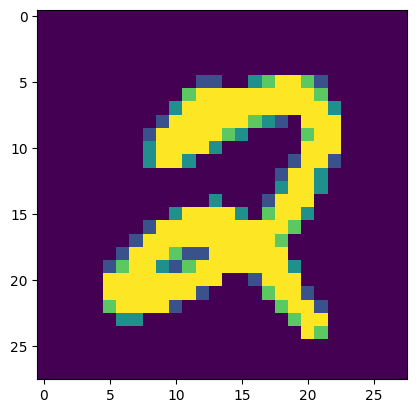

In [22]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0].reshape(28, 28))
plt.show()


In [23]:
X_train[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,  64,  64,   0,   0,
       128, 191, 255, 255, 191,  64,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 191, 25

In [ ]:
# scale the value between [0,1]
X_train=X_train/255
X_test=X_test/255

In [25]:
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [16]:
import torch.nn.functional as F

In [27]:
class Model(nn.Module): #inharite from nn.module class to access the offereing of this class

  def __init__(self, num_features):# build a constructor and inside it we have to give how many features are in the input

    super().__init__()    #invoke/call parents class constructor
    self.fc1=nn.Linear(X_train.shape[1],126)
    self.relu=nn.ReLU()
    self.fc2=nn.Linear(126,256)
    self.relu=nn.ReLU()
    self.fc3=nn.Linear(256,10)
    self.softmax=nn.Softmax()

  def forward(self,features):
    out=self.fc1(features)
    out=self.relu(out)
    out=self.fc2(out)
    out=self.relu(out)
    out=self.fc3(out)
    out=self.softmax(out)
    return out

In [28]:
model=Model(X_train.shape[1])

Epoch 001 | Train Loss: 1.6772 Acc: 0.8001 | Val Loss: 1.6150 Acc: 0.8490
Epoch 005 | Train Loss: 1.4938 Acc: 0.9692 | Val Loss: 1.5000 Acc: 0.9615
Epoch 010 | Train Loss: 1.4800 Acc: 0.9817 | Val Loss: 1.4932 Acc: 0.9684
Epoch 015 | Train Loss: 1.4753 Acc: 0.9864 | Val Loss: 1.4892 Acc: 0.9724
Epoch 020 | Train Loss: 1.4727 Acc: 0.9886 | Val Loss: 1.4881 Acc: 0.9733
Epoch 025 | Train Loss: 1.4713 Acc: 0.9900 | Val Loss: 1.4861 Acc: 0.9747
Epoch 030 | Train Loss: 1.4709 Acc: 0.9903 | Val Loss: 1.4859 Acc: 0.9752
Epoch 035 | Train Loss: 1.4697 Acc: 0.9917 | Val Loss: 1.4854 Acc: 0.9758
Epoch 040 | Train Loss: 1.4689 Acc: 0.9924 | Val Loss: 1.4860 Acc: 0.9751
Epoch 045 | Train Loss: 1.4690 Acc: 0.9922 | Val Loss: 1.4870 Acc: 0.9745
Epoch 050 | Train Loss: 1.4683 Acc: 0.9928 | Val Loss: 1.4847 Acc: 0.9763

Final Val Loss: 1.4847 | Final Val Acc: 0.9763


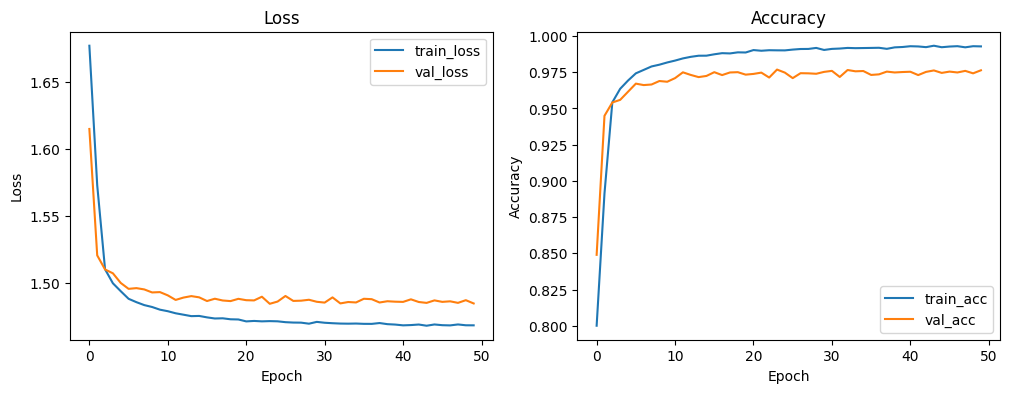

Saved model to multiclass_classification_model.pth


In [33]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Prepare tensors (CPU-only)
# -----------------------------
# X_train, X_test: numpy arrays shape (N, num_features)
# y_train, y_test: numpy arrays of integer class labels shape (N,) (0..num_classes-1)

X_train_t = torch.tensor(X_train, dtype=torch.float32)   # shape (N, D)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

# IMPORTANT: for CrossEntropyLoss labels must be 1D long tensors (no one-hot, no reshape to (N,1))
y_train_t = torch.tensor(y_train.reshape(-1), dtype=torch.long)   # shape (N,)
y_test_t  = torch.tensor(y_test.reshape(-1), dtype=torch.long)

# -----------------------------
# DataLoaders
# -----------------------------
batch_size = 128
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# -----------------------------
# Model (assumes multiclass logits output)
# -----------------------------
# Ensure your Model returns logits with shape (batch, num_classes)
# Example: Model(num_features, n_classes) or similar. If your Model class signature is different,
# adjust instantiation accordingly.
# e.g., model = Model(X_train_t.shape[1], NUM_CLASSES)
model = Model(X_train_t.shape[1])   # <-- ensure this Model returns logits (batch, C)

# -----------------------------
# Loss & optimizer (multiclass)
# -----------------------------
criterion = nn.CrossEntropyLoss()   # expects logits (batch, C) and labels (batch,) long
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# Training config
# -----------------------------
epochs = 50
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, epochs+1):
    # ---------- TRAIN ----------
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        # xb: (batch, D), yb: (batch,) long
        optimizer.zero_grad()
        logits = model(xb)                 # expected shape (batch, num_classes)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)      # predicted class indices
        running_correct += (preds == yb).sum().item()
        running_total += xb.size(0)

    epoch_train_loss = running_loss / running_total
    epoch_train_acc  = running_correct / running_total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # ---------- VALIDATION ----------
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    val_running_total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            loss = criterion(logits, yb)

            val_running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_running_correct += (preds == yb).sum().item()
            val_running_total += xb.size(0)

    epoch_val_loss = val_running_loss / val_running_total
    epoch_val_acc  = val_running_correct / val_running_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} "
              f"| Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

# Final evaluation
print(f"\nFinal Val Loss: {val_losses[-1]:.4f} | Final Val Acc: {val_accs[-1]:.4f}")

# Plot losses and accuracies
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="train_acc")
plt.plot(val_accs, label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy")

plt.show()

# Save model
torch.save(model.state_dict(), "multiclass_classification_model.pth")
print("Saved model to multiclass_classification_model.pth")


In [35]:
# ------------------------------
# Evaluate
# ------------------------------
model.eval()
with torch.no_grad():
    logits = model(X_test_t)                  # shape (N, num_classes)
    y_pred_labels = logits.argmax(dim=1)      # predicted class index

accuracy = (y_pred_labels == y_test_t).sum().item() / len(y_test_t)
print(f"\nTest Accuracy: {accuracy:.4f}")

# ------------------------------
# Predict one example (optional)
# ------------------------------
print("\nExample prediction (logits):")
print(logits[:5])

print("\nPredicted classes:")
print(y_pred_labels[:5])



Test Accuracy: 0.9763

Example prediction (logits):
tensor([[3.0829e-44, 1.9792e-28, 1.8926e-31, 8.7880e-21, 0.0000e+00, 2.8026e-45,
         0.0000e+00, 2.4980e-41, 1.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0622e-42, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
         0.0000e+00, 5.5417e-27, 0.0000e+00, 9.9269e-38],
        [1.5530e-17, 6.5749e-22, 3.8522e-20, 2.6541e-15, 1.4776e-28, 3.9190e-14,
         7.9485e-15, 2.9047e-23, 1.0000e+00, 1.7941e-20],
        [0.0000e+00, 6.0051e-34, 2.4678e-26, 1.1324e-31, 0.0000e+00, 2.2892e-41,
         0.0000e+00, 1.0000e+00, 0.0000e+00, 6.3479e-43],
        [0.0000e+00, 1.8207e-28, 7.4815e-42, 1.5695e-43, 0.0000e+00, 3.3094e-41,
         0.0000e+00, 1.0000e+00, 4.5122e-43, 3.3293e-21]])

Predicted classes:
tensor([8, 4, 8, 7, 7])


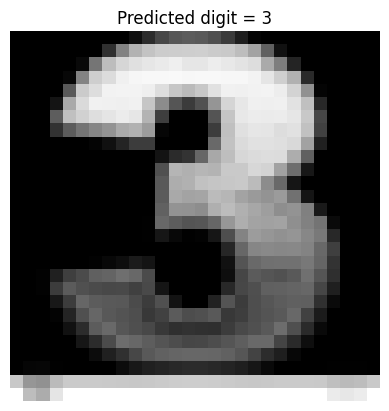

Prediction: 3


In [41]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# --------------------------
# 1. Load your saved model
# --------------------------
model = Model(784)                # your Model class must be defined above
model.load_state_dict(torch.load("multiclass_classification_model.pth"))
model.eval()

# --------------------------
# 2. Preprocessing function
# --------------------------
def preprocess_mnist_image(path):
    """
    Loads any digit image and converts it to the format used during training:
      - grayscale
      - resized to 28x28
      - normalized to [0,1]
      - flattened to (784,)
    """
    img = Image.open(path).convert("L")      # grayscale
    img = img.resize((28, 28))               # MNIST size

    arr = np.array(img).astype("float32") / 255.0  # scale to [0,1]

    # invert if necessary (MNIST digits are white on black)
    if arr.mean() > 0.5:
        arr = 1 - arr

    flat = arr.reshape(-1)                  # flatten to 784
    return flat, arr

# --------------------------
# 3. Predict
# --------------------------
def predict_digit(path):
    flat, arr = preprocess_mnist_image(path)

    x = torch.tensor(flat, dtype=torch.float32).unsqueeze(0)  # shape = (1,784)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).numpy().flatten()

    pred = np.argmax(probs)

    # show image
    plt.imshow(arr, cmap="gray")
    plt.title(f"Predicted digit = {pred}")
    plt.axis("off")
    plt.show()

    return pred, probs

# --------------------------
# 4. Run prediction
# --------------------------
pred, probs = predict_digit("test_digit1.png")   # <-- your test image path
print("Prediction:", pred)

